# Aula 11 — Matplotlib Fundamentos: gráficos para relatórios econômicos
Semana 6 | 50 min | Referências: VanderPlas, Cap. 4 (*Visualization with Matplotlib*) · McKinney, Cap. 8 (*Plotting and Visualization*)

## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- **Criar gráficos pela interface orientada a objetos**: `fig, ax = plt.subplots()`, sabendo o que é Figure (a folha) e Axes (o quadro).
- **Construir os dois gráficos do dia a dia econômico**: linhas para séries temporais (Selic × IPCA do BCB) e barras para comparações categóricas (renda média por UF, POF/IBGE).
- **Customizar como relatório profissional**: título que enuncia a conclusão, legendas, grids, formatação de moeda em R$ com `FuncFormatter` + `brl()`.
- **Montar painéis com subplots** e **exportar figuras a 300 dpi** prontas para Word/PDF.

## 1. Por que gráficos (e não tabelas)

Uma tabela com 2.430 linhas da Selic diária não cabe em relatório; a mesma série
desenhada conta o ciclo de juros em dois segundos. Gráfico é **argumento condensado**:
tem uma mensagem, e o título é quem a enuncia.

Nesta aula usamos duas fontes reais:

- **BCB**: `selic_diaria_aa.csv` (Selic diária, % a.a.) e `ipca_mensal.csv` (IPCA mensal, %);
- **POF 2017-18 (IBGE)**: renda per capita da pessoa de referência por UF.

A interface OO é a base de tudo: `plt.subplots()` devolve a **Figure** (a folha, que
você exporta) e o **Axes** (o quadro onde se desenha).

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

DATA = Path("../data/csv")  # notebook mora em semana_06/

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Formatter de reais para os eixos — aplicado com ax.yaxis.set_major_formatter(fmt_brl)
fmt_brl = FuncFormatter(lambda v, _: brl(v))

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade

## 2. Anatomia OO: Figure, Axes e Axis

Três camadas:

| Objeto | Papel | Analogia |
|---|---|---|
| `Figure` | a folha inteira, que você exporta com `savefig` | o papel |
| `Axes` | um gráfico: título, eixos, séries, legenda | o quadro no papel |
| `Axis` | um eixo individual: ticks, rótulos, escala | a régua do quadro |

**Regra da aula**: desenhe sempre no `ax` (`ax.plot`, `ax.bar`), customize no `ax`,
exporte a `fig`. Isso escala para qualquer número de painéis.

type(fig) = Figure
type(ax)  = Axes
eixo Y: YAxis(87.5,38.49999999999999)


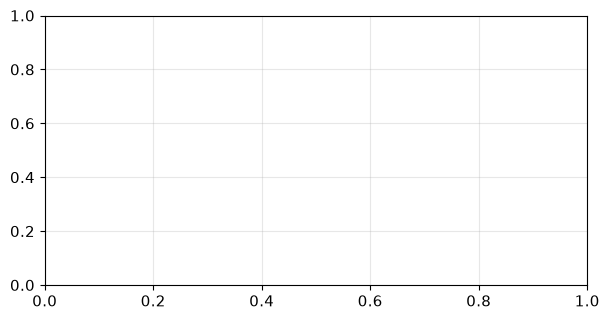

In [2]:
# fig, ax = plt.subplots() devolve DOIS objetos: a folha e o quadro
fig, ax = plt.subplots(figsize=(7, 3.5))

print("type(fig) =", type(fig).__name__)   # Figure — a folha inteira
print("type(ax)  =", type(ax).__name__)    # Axes   — um quadro dentro da folha

# O eixo Y do quadro é um objeto Axis com seus próprios ticks:
print("eixo Y:", ax.yaxis)
plt.show()

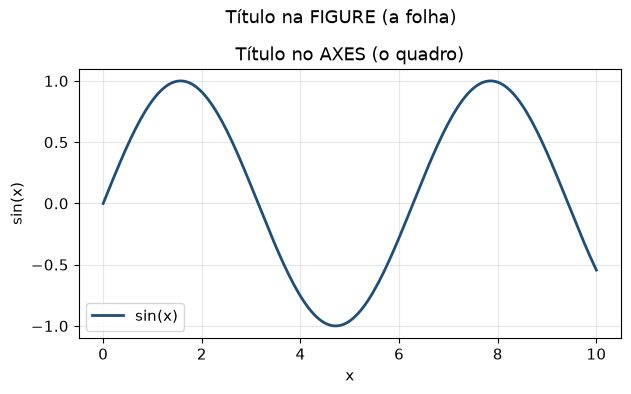

In [3]:
# Anatomia na prática: o MESMO desenho, customizado pelo ax
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.linspace(0, 10, 200)
ax.plot(x, np.sin(x), color="#1f4e79", lw=2, label="sin(x)")   # desenho NO quadro
ax.set_title("Título no AXES (o quadro)")                      # título do quadro
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.legend()
fig.suptitle("Título na FIGURE (a folha)", y=1.05)             # título da folha
plt.show()

## 3. Linhas: a Selic vs o IPCA (séries do BCB)

Selic é **diária, % a.a.**; o IPCA do CSV é **mensal, % no mês**. Sobrepor as duas
assim seria comparar reais com dólar. A ponte é acumular o IPCA em 12 meses:

$$I_{12} = \prod_{t=1}^{12}(1+i_t) - 1$$

Com as duas séries em **% a.a.**, a distância vertical entre as linhas aproxima o
**juro real ex-post** (relação de Fisher). Lemos o BCB com `sep=';'`, `decimal=','`
e datas explícitas (`dayfirst=True`) — o padrão brasileiro.

In [4]:
# Leitura das séries do BCB — padrão brasileiro: sep=';' e decimal=','
selic = pd.read_csv(DATA / "selic_diaria_aa.csv", sep=";")
selic["data"] = pd.to_datetime(selic["data"], format="%d/%m/%Y", dayfirst=True)
selic["valor"] = pd.to_numeric(selic["valor"].str.replace(",", "."))  # CSV brasileiro: vírgula decimal

ipca = pd.read_csv(DATA / "ipca_mensal.csv", sep=";", decimal=",")
ipca["data"] = pd.to_datetime(ipca["data"], format="%d/%m/%Y", dayfirst=True)

print(selic.dtypes)
selic.tail(3)

data     datetime64[us]
valor           float64
dtype: object


,data,valor
2426,2026-09-02,13.9
2427,2026-09-03,13.9
2428,2026-09-04,13.9


In [5]:
# Ponte de unidade: IPCA mensal -> acumulado em 12 meses (% a.a.)
# I_12 = prod(1 + i_t) - 1  sobre uma janela móvel de 12 meses
ipca["acum12"] = ((1 + ipca["valor"] / 100).rolling(12).apply(np.prod, raw=True) - 1) * 100
ipca = ipca.dropna(subset=["acum12"])
ipca = ipca[ipca["data"] >= "2017-01-01"]  # mesma janela da Selic do CSV (2017→2026)

# Referências para o relatório (set/2026): Selic 13,90% a.a.; IPCA 12m ~4,4%
print("IPCA 12m em jul/2026:", round(ipca["acum12"].iloc[-1], 2), "%")
print("Selic em set/2026  :", selic["valor"].iloc[-1], "% a.a.")
ipca.tail(3)

IPCA 12m em jul/2026: 4.44 %
Selic em set/2026  : 13.9 % a.a.


,data,valor,acum12
556,2026-05-01,0.58,4.724907
557,2026-06-01,0.16,4.641328
558,2026-07-01,0.07,4.443025


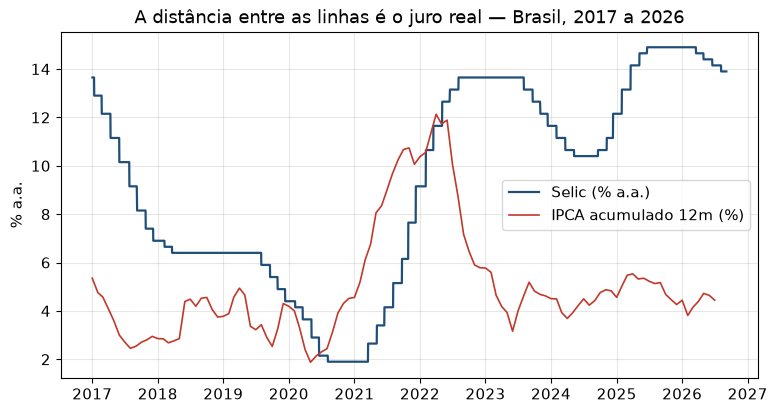

In [6]:
# O gráfico-linha essencial: duas séries no mesmo quadro
fig, ax = plt.subplots()
ax.plot(selic["data"], selic["valor"], color="#1f4e79", lw=1.6, label="Selic (% a.a.)")
ax.plot(ipca["data"], ipca["acum12"], color="#c0392b", lw=1.2,
        label="IPCA acumulado 12m (%)")
ax.set_title("A distância entre as linhas é o juro real — Brasil, 2017 a 2026")
ax.set_ylabel("% a.a.")
ax.legend()
plt.show()

# Leitura econômica: queda até 1,90% a.a. (pandemia), aperto 2022-23,
# patamar de 13,90% a.a. com inflação de ~4,4% — juro real de dois dígitos.

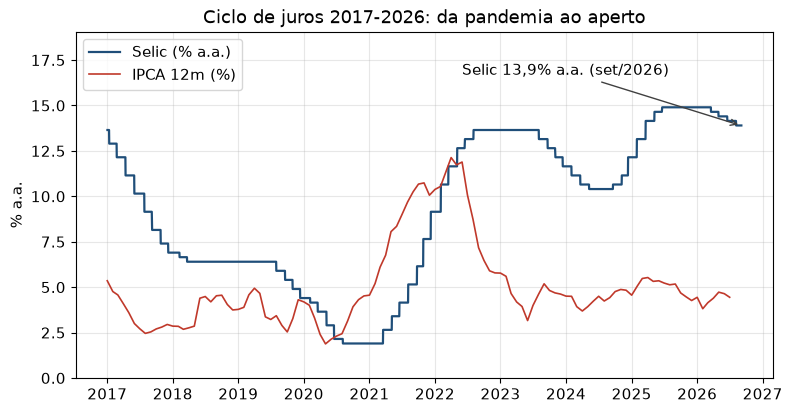

In [7]:
# Anotação: destacar um número que importa com ax.annotate
fig, ax = plt.subplots()
ax.plot(selic["data"], selic["valor"], color="#1f4e79", lw=1.6, label="Selic (% a.a.)")
ax.plot(ipca["data"], ipca["acum12"], color="#c0392b", lw=1.2, label="IPCA 12m (%)")

selic_set26 = selic.loc[selic["data"] >= "2026-09-01", "valor"].iloc[0]
y_max = selic["valor"].max()
ax.set_ylim(0, y_max * 1.28)  # folga no topo para a anotação não cortar
ax.annotate(f"Selic {str(selic_set26).replace('.', ',')}% a.a. (set/2026)",
            xy=(pd.Timestamp("2026-09-01"), selic_set26),
            xytext=(pd.Timestamp("2022-06-01"), y_max * 1.12),
            arrowprops=dict(arrowstyle="->", color="0.25"))
ax.set_title("Ciclo de juros 2017-2026: da pandemia ao aperto")
ax.set_ylabel("% a.a.")
ax.legend()
plt.show()

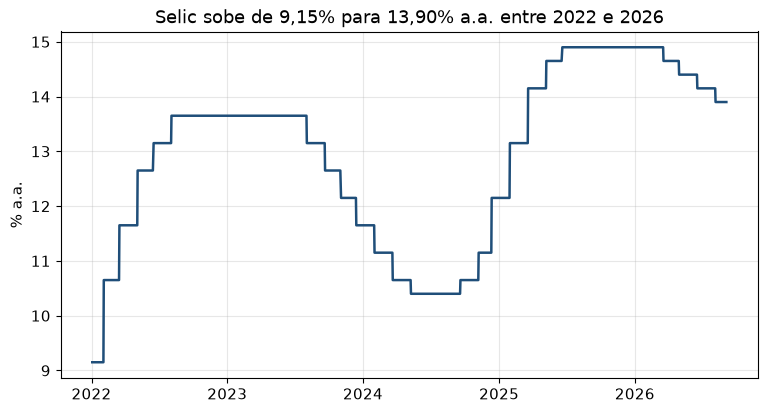

In [8]:
# Zoom: mesma série, janela 2022→2026 — quando o contexto muda, reenquadre
recente = selic[selic["data"] >= "2022-01-01"]
fig, ax = plt.subplots()
ax.plot(recente["data"], recente["valor"], color="#1f4e79", lw=1.8)
ax.set_title("Selic sobe de 9,15% para 13,90% a.a. entre 2022 e 2026")
ax.set_ylabel("% a.a.")
plt.show()

## 4. Barras: renda média por UF (POF 2017-18)

Barras comparam **categorias**. Vamos mesclar `pof_morador.csv` (RENDA_PC por
domicílio) com `pof_domicilio.csv` (UF), agregar a média por UF e ordenar. O
destaque de cor em Goiás (UF = 52) faz o olho do leitor achar o estado em meio às
27 barras — customização a serviço da mensagem.

In [9]:
# Merge POF: renda per capita (morador) + UF (domicílio), pela chave household_id
pof = pd.read_csv(DATA / "pof_morador.csv").merge(
    pd.read_csv(DATA / "pof_domicilio.csv"), on="household_id", validate="many_to_one"
)
print(f"{len(pof):,} pessoas de referência | UF 52 = Goiás, 53 = DF")
renda_uf = pof.groupby("UF")["RENDA_PC"].mean().sort_values(ascending=False)
print("Top 3 UFs:", {int(k): round(v) for k, v in renda_uf.head(3).items()})
print("Goiás (52):", "R$ {:,.0f}".format(renda_uf[52]).replace(",", "."))

58,039 pessoas de referência | UF 52 = Goiás, 53 = DF
Top 3 UFs: {53: 3300, 35: 2460, 43: 2340}
Goiás (52): R$ 1.701


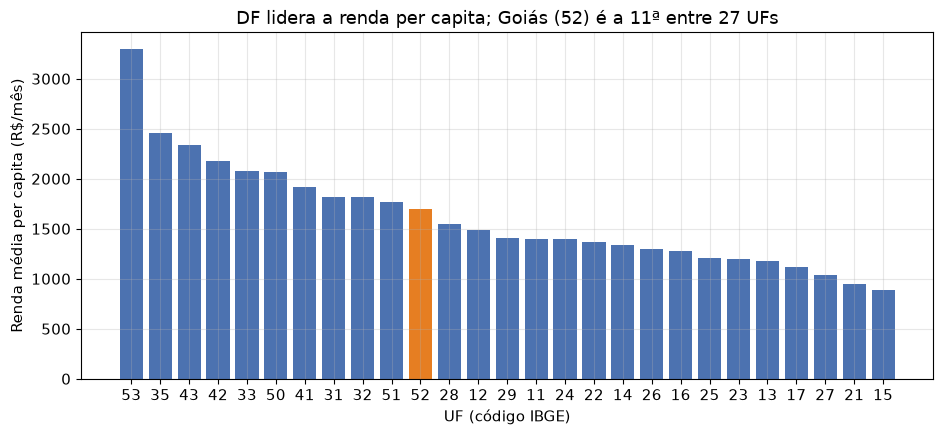

In [10]:
# Barras: 27 UFs, ordenadas, com Goiás destacado
cores = ["#e67e22" if uf == 52 else "#4c72b0" for uf in renda_uf.index]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(renda_uf.index.astype(str), renda_uf.values, color=cores)
ax.set_title("DF lidera a renda per capita; Goiás (52) é a 11ª entre 27 UFs")
ax.set_xlabel("UF (código IBGE)")
ax.set_ylabel("Renda média per capita (R$/mês)")
plt.show()

## 5. Customização profissional: título-enunciado, legenda, grid e reais

O que separa "gráfico de aula" de "figura de relatório":

1. **Título que enuncia a conclusão** (não "Gráfico 3");
2. Eixos rotulados **com unidade** (R$/mês, % a.a.);
3. Moeda em formato brasileiro — `FuncFormatter` aplicando `brl()` nos ticks;
4. Grid discreto (`alpha` baixo) que guia o olho sem competir;
5. Valores escritos **dentro** do gráfico quando são poucos (`ax.text`).

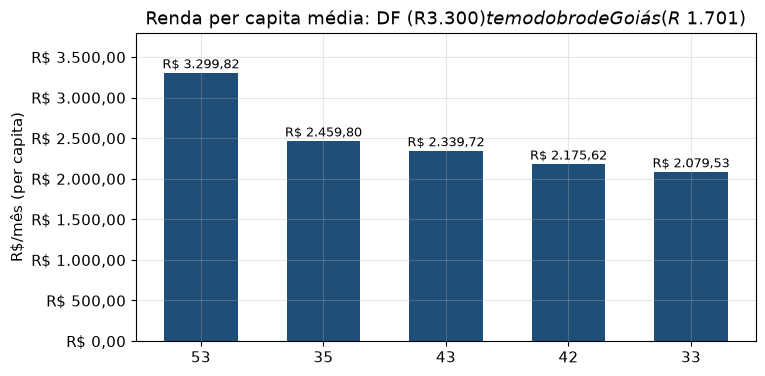

In [11]:
# A mesma renda por UF, agora em versão "relatório": formatter de reais + valores
top5 = renda_uf.head(5)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(top5.index.astype(str), top5.values, color="#1f4e79", width=0.6)
ax.yaxis.set_major_formatter(fmt_brl)          # ticks viram R$ 1.234,56
ax.set_title("Renda per capita média: DF (R$ 3.300) tem o dobro de Goiás (R$ 1.701)")
ax.set_ylabel("R$/mês (per capita)")
for i, v in enumerate(top5.values):            # valor escrito sobre cada barra
    ax.text(i, v + 60, brl(v), ha="center", fontsize=9)
ax.set_ylim(0, top5.values.max() * 1.15)       # folga para o texto não cortar
plt.show()

## 6. Subplots: painéis na mesma folha

`fig, axes = plt.subplots(nrows, ncols)` devolve um **array** de Axes:
`axes[0]`, `axes[1]` (1-D) ou `axes[0, 0]` (grade 2×2). Com `sharey=True` os
painéis ficam comparáveis de verdade — mesma régua. `fig.suptitle()` dá o título
da folha inteira.

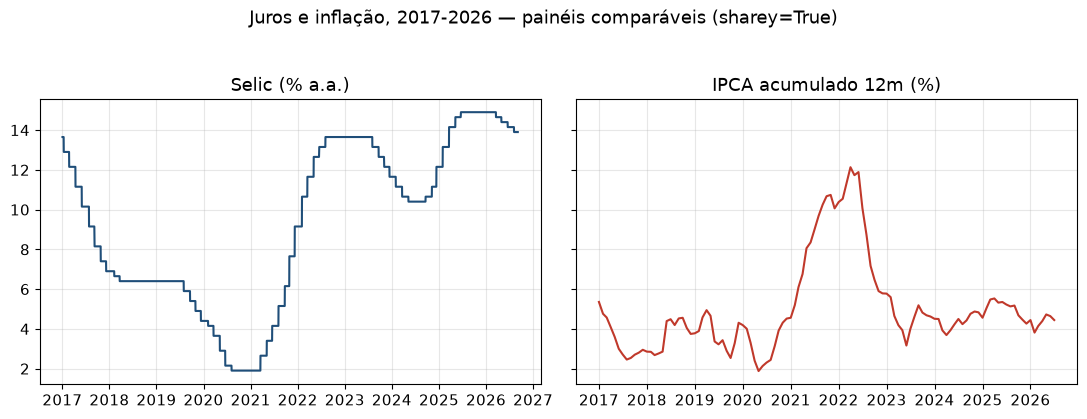

axes é um array: ndarray (2,)


In [12]:
# 1 linha x 2 colunas: Selic | IPCA 12m, cada série em seu painel
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].plot(selic["data"], selic["valor"], color="#1f4e79")
axes[0].set_title("Selic (% a.a.)")
axes[1].plot(ipca["data"], ipca["acum12"], color="#c0392b")
axes[1].set_title("IPCA acumulado 12m (%)")
fig.suptitle("Juros e inflação, 2017-2026 — painéis comparáveis (sharey=True)", y=1.04)
fig.tight_layout()
plt.show()
print("axes é um array:", type(axes).__name__, axes.shape)

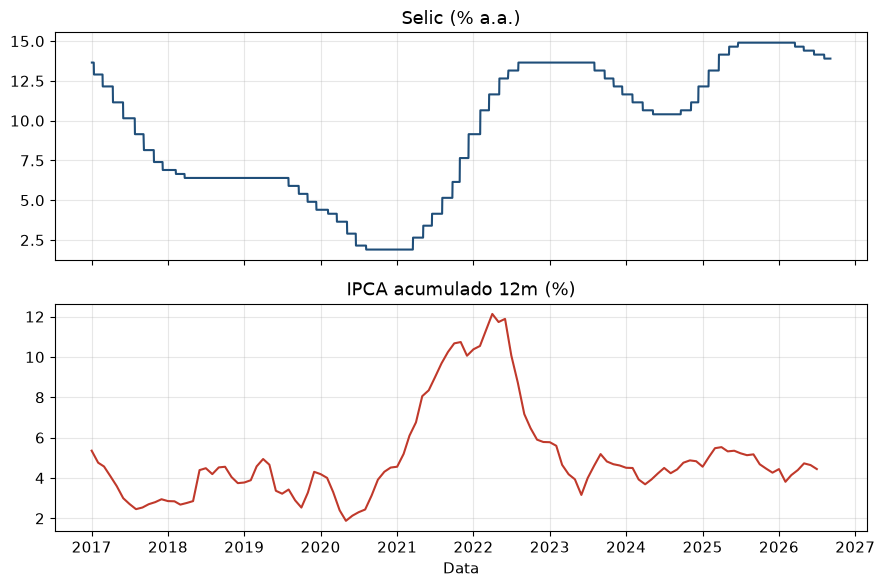

In [13]:
# 2 linhas x 1 coluna com eixo X compartilhado (sharex=True)
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(selic["data"], selic["valor"], color="#1f4e79")
axes[0].set_title("Selic (% a.a.)")
axes[1].plot(ipca["data"], ipca["acum12"], color="#c0392b")
axes[1].set_title("IPCA acumulado 12m (%)")
axes[1].set_xlabel("Data")
fig.tight_layout()
plt.show()

## 7. Exportar: savefig com dpi=300

PNG a **300 dpi** é o padrão editorial para Word/PDF impresso. `bbox_inches="tight"`
remove margem branca excessiva; `.pdf`/`.svg` ficam vetoriais (zoom sem pixelizar).
Em scripts `.py`, salve **antes** de `plt.show()`.

PNG salvo: 149 KB


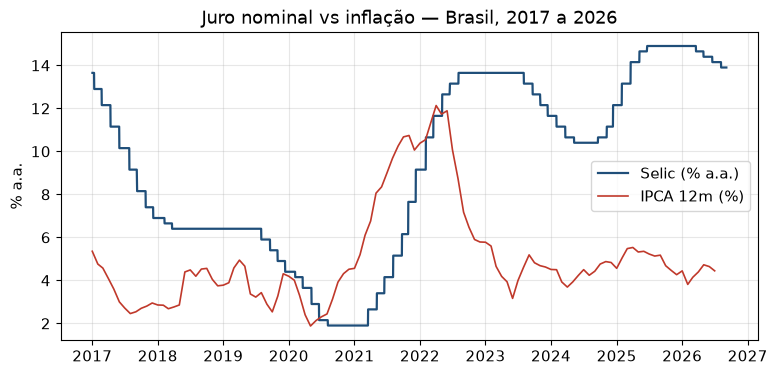

In [14]:
# Exportação da figura de juros para o relatório
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(selic["data"], selic["valor"], color="#1f4e79", lw=1.6, label="Selic (% a.a.)")
ax.plot(ipca["data"], ipca["acum12"], color="#c0392b", lw=1.2, label="IPCA 12m (%)")
ax.set_title("Juro nominal vs inflação — Brasil, 2017 a 2026")
ax.set_ylabel("% a.a.")
ax.legend()

fig.savefig("fig_selic_2022_2026.png", dpi=300, bbox_inches="tight")
print("PNG salvo:", Path("fig_selic_2022_2026.png").stat().st_size // 1024, "KB")
plt.show()

## 📝 Exercícios

Tente antes de abrir a solução. Todos usam os objetos já criados
(`pof`, `renda_uf`, `selic`, `ipca`, `fmt_brl`, `brl`).

### Exercício 1 — Urbano × rural em barras

Usando o `pof` já mesclado, calcule a renda per capita média por `SITUACAO`
(1 = urbano, 2 = rural) e desenhe **2 barras** com o eixo Y em reais (`fmt_brl`).
Título com a conclusão: qual a diferença em R$/mês?

In [15]:
# EXERCÍCIO 1 — seu código aqui

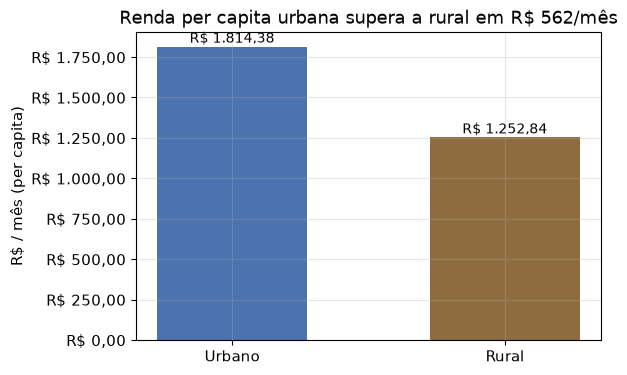

SITUACAO
1    1814.382715
2    1252.844249
Name: RENDA_PC, dtype: float64


In [16]:
# SOLUÇÃO 1 — barras urbano x rural com formatter de reais
media_sit = pof.groupby("SITUACAO")["RENDA_PC"].mean()   # 1=urbano, 2=rural
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Urbano", "Rural"], media_sit.values, color=["#4c72b0", "#8e6c3f"], width=0.55)
ax.yaxis.set_major_formatter(fmt_brl)
ax.set_title(f"Renda per capita urbana supera a rural em "
             f"R$ {media_sit[1] - media_sit[2]:,.0f}/mês")
ax.set_ylabel("R$ / mês (per capita)")
for i, v in enumerate(media_sit.values):
    ax.text(i, v + 25, brl(v), ha="center", fontsize=10)
plt.show()
print(media_sit)

### Exercício 2 — O pico do IPCA mensal (2024→2026)

Filtre o IPCA de jan/2024 em diante, desenhe **barras mensais** e pinte de
vermelho **só a barra do pico** (dica: `idxmax()` + lista de cores). Título
enunciando mês e valor do pico.

In [17]:
# EXERCÍCIO 2 — seu código aqui

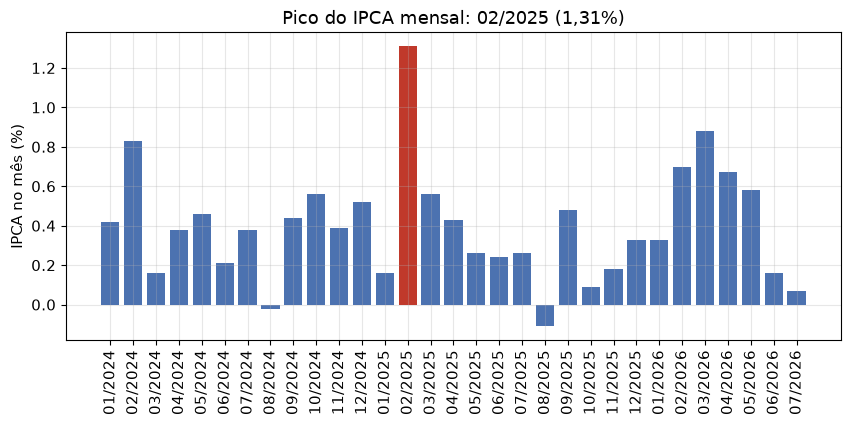

In [18]:
# SOLUÇÃO 2 — barras do IPCA mensal com o pico destacado
i3 = ipca[ipca["data"] >= "2024-01-01"]
imax = i3["valor"].idxmax()                       # índice da linha do máximo
cores = ["#c0392b" if idx == imax else "#4c72b0" for idx in i3.index]
pico_txt = f"{i3.loc[imax, 'valor']:.2f}".replace(".", ",")
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(i3["data"].dt.strftime("%m/%Y"), i3["valor"], color=cores)
ax.set_title(f"Pico do IPCA mensal: {i3.loc[imax, 'data'].strftime('%m/%Y')} ({pico_txt}%)")
ax.set_ylabel("IPCA no mês (%)")
ax.tick_params(axis="x", rotation=90)
plt.show()

### Exercício 3 — Média vs mediana por UF (subplots)

Nas **5 UFs mais ricas**, desenhe dois painéis lado a lado (`sharey=True`):
média da RENDA_PC à esquerda, mediana à direita. Pergunta-guia: a média fica
**acima** da mediana mesmo nas UFs ricas? O que isso indica sobre a distribuição?

In [19]:
# EXERCÍCIO 3 — seu código aqui

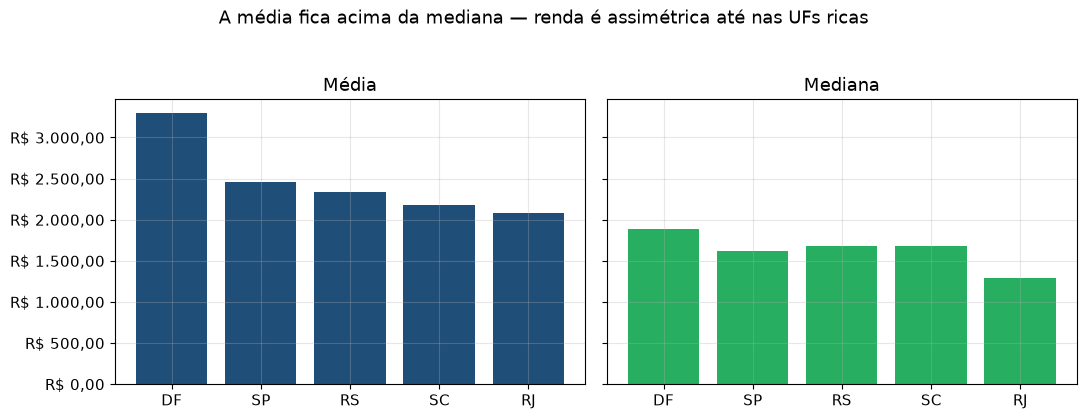

In [20]:
# SOLUÇÃO 3 — média vs mediana nas 5 UFs mais ricas
UF_SIGLA = {53: "DF", 35: "SP", 43: "RS", 42: "SC", 33: "RJ", 50: "MS", 41: "PR",
            31: "MG", 32: "ES", 51: "MT", 52: "GO"}
est = pof.groupby("UF")["RENDA_PC"].agg(["mean", "median"]).loc[renda_uf.head(5).index]
siglas = [UF_SIGLA[u] for u in est.index]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].bar(siglas, est["mean"], color="#1f4e79")
axes[0].set_title("Média")
axes[1].bar(siglas, est["median"], color="#27ae60")
axes[1].set_title("Mediana")
for ax in axes:
    ax.yaxis.set_major_formatter(fmt_brl)
fig.suptitle("A média fica acima da mediana — renda é assimétrica até nas UFs ricas",
             y=1.04)
fig.tight_layout()
plt.show()

### Exercício 4 — Sua primeira figura de relatório (300 dpi)

Refaça o gráfico Selic × IPCA 12m com legendas e título-enunciado e **exporte**
para `fig_a11_ex4_juro_inflacao.png` com `dpi=300, bbox_inches="tight"`.
Confirme o tamanho do arquivo com `Path(...).stat().st_size`.

In [21]:
# EXERCÍCIO 4 — seu código aqui

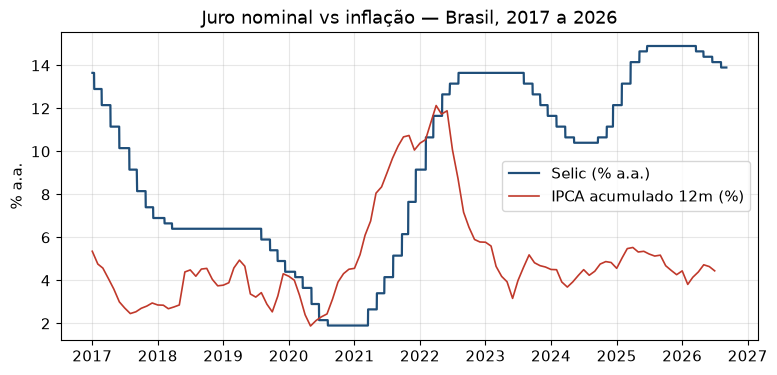

PNG salvo: 152 KB


In [22]:
# SOLUÇÃO 4 — exportando a figura de juros e inflação a 300 dpi
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(selic["data"], selic["valor"], color="#1f4e79", lw=1.6, label="Selic (% a.a.)")
ax.plot(ipca["data"], ipca["acum12"], color="#c0392b", lw=1.2,
        label="IPCA acumulado 12m (%)")
ax.set_title("Juro nominal vs inflação — Brasil, 2017 a 2026")
ax.set_ylabel("% a.a.")
ax.legend()
fig.savefig("fig_a11_ex4_juro_inflacao.png", dpi=300, bbox_inches="tight")
plt.show()
print("PNG salvo:", Path("fig_a11_ex4_juro_inflacao.png").stat().st_size // 1024, "KB")

## 📌 Resumo & para casa

- **Interface OO sempre**: `fig, ax = plt.subplots()`; desenhe no `ax`, exporte a `fig`. Escala para subplots sem retrabalho.
- **Título enuncia a mensagem** ("A distância entre as linhas é o juro real"), nunca descreve o que foi plotado.
- **Comparar séries exige mesma unidade**: IPCA mensal → acumulado 12m antes de sobrepor com a Selic (% a.a.).
- **Moeda em R$ nos ticks**: `ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: brl(v)))`.
- **Destaque de cor** (Goiás em laranja, pico do IPCA em vermelho) orienta o olho do leitor.
- **`savefig(dpi=300, bbox_inches="tight")`** é o padrão para Word/PDF; PDF/SVG para versão vetorial.
- **Para casa**: pegue um relatório econômico recente (BCB, IPEA, jornal) e identifique 2 gráficos cujo título *enuncia* a mensagem e 2 que apenas *descrevem*; reescreva os maus títulos.
- **Próxima aula**: seaborn — histograma, boxplot, regressão e heatmap com uma linha de código.

**Referências (KB)**:
- `kb/02_vanderplas_python_data_science_handbook/07_chapter-4-visualization-with-matplotlib.md`
- `kb/01_mckinney_python_for_data_analysis/10_chapter-8-plotting-and-visualization.md`